EXPERIMENTING WITH IMAGE ENHANCEMENT TECHNIQUES

In [ ]:
import cv2
import numpy as np
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

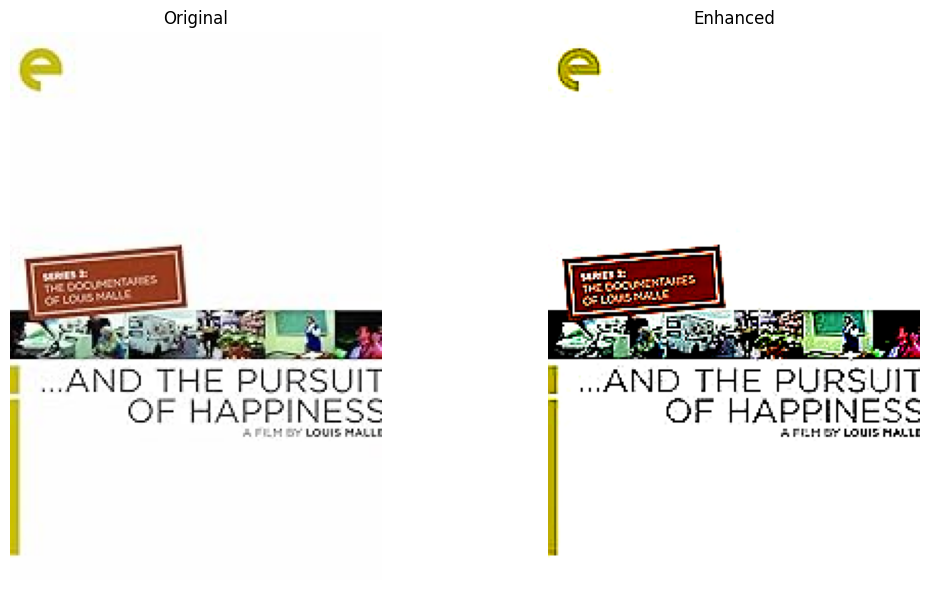

In [ ]:
#load an example image (change according to your path)
img_path = r"C:\Users\tessj\.cache\kagglehub\datasets\afsadasasdasdas\computer-vision-project-dataset\versions\1\poster_images\poster_images\...And_the_Pursuit_of_Happiness_1986_.jpg"
original = Image.open(img_path).convert("RGB")

#increase contrast and sharpness
enhancer_contrast = ImageEnhance.Contrast(original)
enhanced = enhancer_contrast.enhance(1.5)  

enhancer_sharpness = ImageEnhance.Sharpness(enhanced)
enhanced = enhancer_sharpness.enhance(3.0)  

#original vs enhanced
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(original)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Enhanced")
plt.imshow(enhanced)
plt.axis('off')

plt.tight_layout()
plt.show()


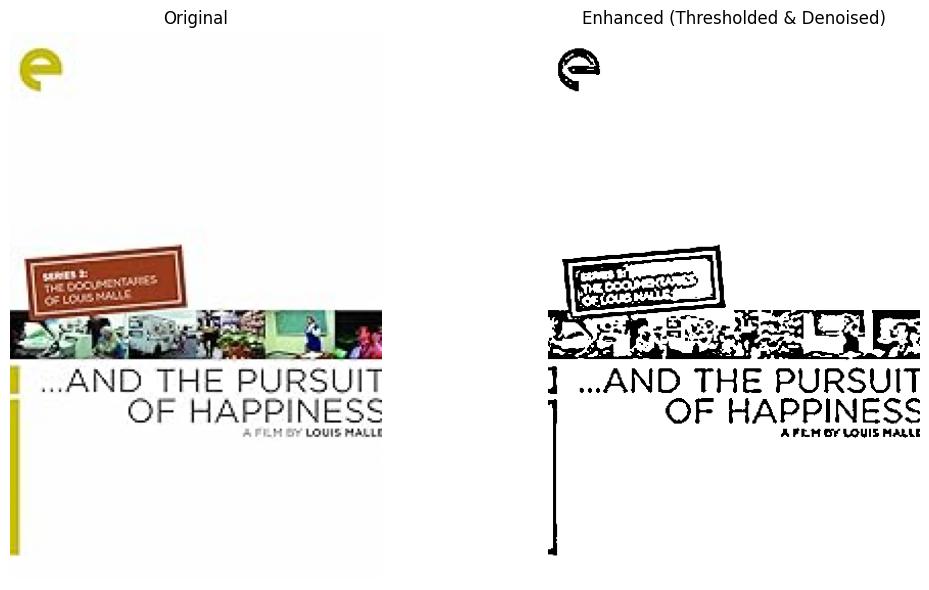

In [ ]:

img_path = r"C:\Users\tessj\.cache\kagglehub\datasets\afsadasasdasdas\computer-vision-project-dataset\versions\1\poster_images\poster_images\...And_the_Pursuit_of_Happiness_1986_.jpg"

original = Image.open(img_path).convert("RGB")
cv_img = np.array(original)
cv_img = cv2.cvtColor(cv_img, cv2.COLOR_RGB2BGR)

#convert to grayscale 
gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

#resize (2x)
scaled = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

#adaptive thresholding
thresh = cv2.adaptiveThreshold(scaled, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY, 31, 15)

#denoise
enhanced = cv2.fastNlMeansDenoising(thresh, h=30)

#Convert back to PIL for matplotlib
enhanced_img = Image.fromarray(enhanced)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(original)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Enhanced (Thresholded & Denoised)")
plt.imshow(enhanced_img, cmap="gray")
plt.axis('off')

plt.tight_layout()
plt.show()


EASYOCR TEXT EXTRACTION ==> BEST FOR OUR CASE

LANGUAGE DETECTION TO IMPROVE TEXT EXTRACTION

In [ ]:
import pandas as pd
from langdetect import detect, DetectorFactory
from tqdm import tqdm


DetectorFactory.seed = 0


csv_path = r"C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\poster_titles_cleaned.csv" #change path accordingly
df = pd.read_csv(csv_path)

#detect language for each movie name
langs = []
for name in tqdm(df['title'], desc="Detecting languages"):
    try:
        lang = detect(name)
    except:
        lang = 'unknown'
    langs.append(lang)

df['DetectedLanguage'] = langs


counts = df['DetectedLanguage'].value_counts()

print("\n Language distribution:")
print(counts)


df.to_csv(r"C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\dataset_with_languages.csv", index=False, encoding='utf-8') #change accordingly


Detecting languages: 100%|██████████| 30245/30245 [04:17<00:00, 117.35it/s]


 Language distribution:
en         15681
de          2068
fr          1134
it          1124
id           858
tl           804
nl           722
es           602
af           565
fi           529
sw           507
no           500
so           492
pt           475
ro           434
da           413
ca           408
cy           378
sv           360
et           357
pl           298
tr           282
hr           231
sl           229
lt           194
sk           122
sq           121
hu            84
cs            84
vi            75
unknown       69
lv            45
Name: DetectedLanguage, dtype: int64


BATCH CREATION

In [ ]:
import pandas as pd
import math
import os

df = pd.read_csv(r"C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\dataset_with_languages.csv") #change accordingly

output_dir = r"C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches" #change accordingly
os.makedirs(output_dir, exist_ok=True)

#split
batch_size = 5000
num_batches = math.ceil(len(df) / batch_size)

for i in range(num_batches):
    batch_df = df.iloc[i * batch_size : (i + 1) * batch_size]
    batch_path = os.path.join(output_dir, f"batch_{i+1}.csv")
    batch_df.to_csv(batch_path, index=False)
    print(f" Saved {batch_path} ({len(batch_df)} rows)")


 Saved C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches\batch_1.csv (5000 rows)
 Saved C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches\batch_2.csv (5000 rows)
 Saved C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches\batch_3.csv (5000 rows)
 Saved C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches\batch_4.csv (5000 rows)
 Saved C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches\batch_5.csv (5000 rows)
 Saved C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches\batch_6.csv (5000 rows)
 Saved C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches\batch_7.csv (245 rows)


batch for poster_text_results_batch_2.csv

In [ ]:
import pandas as pd
import os


df = pd.read_csv(r"C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\dataset_with_languages.csv") #change accordingly


start_row = 1593 + 1  # 1594th row 
end_row = start_row + 1500  # Up to 3094th row 


subset_df = df.iloc[start_row:end_row]


output_dir = r"C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches" #change accordingly
os.makedirs(output_dir, exist_ok=True)


subset_path = os.path.join(output_dir, "batch_from_1594_to_3093.csv")
subset_df.to_csv(subset_path, index=False)

print(f"Saved {subset_path} ({len(subset_df)} rows)")


Saved C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches\batch_from_1594_to_3093.csv (1500 rows)


TEXT EXTRACTION (sample results for 1500 posters in : poster_text_results_batch_1.csv / poster_text_results_batch_2.csv)

In [ ]:
import easyocr
import cv2
import numpy as np
import pandas as pd
import requests
from PIL import Image, ImageEnhance
from io import BytesIO
from imdb import IMDb
import os

# IMDb instance
ia = IMDb()

input_csv_path = r'C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\batches\batch_from_1594_to_3093.csv' #change accordingly
df = pd.read_csv(input_csv_path)
titles_and_langs = df[["title", "DetectedLanguage"]].values.tolist()

#mapping from langdetect codes to EasyOCR supported codes
lang_map = {
    'en': 'en', 'de': 'de', 'fr': 'fr', 'it': 'it', 'tl': 'tl', 'id': 'id', 'nl': 'nl', 'af': 'af', 'es': 'es',
    'pt': 'pt', 'no': 'no', 'sw': 'sw', 'ro': 'ro', 'da': 'da', 'sv': 'sv', 'cy': 'cy', 'et': 'et', 'pl': 'pl',
    'hr': 'hr', 'tr': 'tr', 'sl': 'sl', 'sq': 'sq', 'lt': 'lt', 'sk': 'sk', 'hu': 'hu', 'cs': 'cs', 'vi': 'vi',
    'lv': 'lv'
}

#function to get poster and preprocess it
def fetch_and_preprocess(title):
    try:
        results = ia.search_movie(title)
        if not results:
            return None, f"Movie '{title}' not found on IMDb"

        movie = results[0]
        ia.update(movie)
        poster_url = movie.get("full-size cover url") or movie.get("cover url")

        if not poster_url:
            return None, None, f"No poster for '{title}'"

        #download and preprocess
        response = requests.get(poster_url)
        pil_img = Image.open(BytesIO(response.content)).convert("RGB") #ensures it's in RGB format
        gray = pil_img.convert("L") #text detection works better on simpler grayscale images because color can introduce noise
        gray = ImageEnhance.Contrast(gray).enhance(1.8) #enhances the difference between text and background, especially useful if the poster is faded or low-contrast
        img = cv2.cvtColor(np.array(gray), cv2.COLOR_GRAY2BGR)
        img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)#image upscaling to help ocr detect the smaller fonts

        return img, poster_url, None
    except Exception as e:
        return None, None, str(e)

#function to extract top 3 lines of text
def extract_top_3_lines(img, lang_code):
    reader = easyocr.Reader([lang_code], gpu=True)
    result = reader.readtext(img, detail=1, paragraph=False)
    text_data = []

    for (bbox, text, conf) in result:
        if conf > 0.5:
            y1 = bbox[0][1]
            y2 = bbox[2][1]
            height = abs(y2 - y1)
            text_data.append((text.strip(), height, conf))

    top_lines = sorted(text_data, key=lambda x: -x[1])[:3]
    return [line[0] for line in top_lines]

#process each poster
#load previously saved results if file exists
output_file = "poster_text_results_batch_2.csv" #change accordingly

if os.path.exists(output_file):
    output_df = pd.read_csv(output_file)
    processed_titles = set(output_df["Title"].dropna().unique())
    all_results = output_df.to_dict(orient='records')  # resume appending
    print(f"Resuming from previous run. {len(processed_titles)} titles already processed.")
else:
    processed_titles = set()
    all_results = []

for title, detected_lang in titles_and_langs:
    if title in processed_titles:
        print(f"Skipping already processed: {title}")
        continue

    print(f"Processing: {title} [{detected_lang}]")

    lang_code = lang_map.get(detected_lang, 'en')  # default to English if unsupported
    img, poster_url, error = fetch_and_preprocess(title)

    #error handling
    if error:
        result = {
            "Title": title,
            "Poster URL": "",
            "Detected Language": detected_lang,
            "Line 1": "",
            "Line 2": "",
            "Line 3": "",
            "Error": error
        }

    else:
        lines = extract_top_3_lines(img, lang_code)
        result = {
            "Title": title,
            "Poster URL": poster_url,
            "Detected Language": detected_lang,
            "Line 1": lines[0] if len(lines) > 0 else "",
            "Line 2": lines[1] if len(lines) > 1 else "",
            "Line 3": lines[2] if len(lines) > 2 else "",
            "Error": ""
        }
    all_results.append(result)
    pd.DataFrame(all_results).to_csv(output_file, index=False)
    print(f" Saved {title}")



#automatically download IN COLLAB
#from google.colab import files
#files.download(output_file)

Processing: Central Station [en]


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\tessj\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 Saved Central Station
Processing: Savior [it]


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\tessj\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 Saved Savior
Processing: Waking Ned Devine [nl]


...

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\tessj\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 Saved The Dark Half
Processing: Gulliver s Travels [no]


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\tessj\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


 Saved Gulliver s Travels
Processing: Monkey Shines [en]


KeyboardInterrupt: 

In [1]:
!! pip install transformers


['Requirement already satisfied: transformers in c:\\users\\tessj\\appdata\\local\\programs\\python\\python311\\lib\\site-packages (4.51.3)',
 'Requirement already satisfied: filelock in c:\\users\\tessj\\appdata\\local\\programs\\python\\python311\\lib\\site-packages (from transformers) (3.16.1)',
 'Requirement already satisfied: huggingface-hub<1.0,>=0.30.0 in c:\\users\\tessj\\appdata\\local\\programs\\python\\python311\\lib\\site-packages (from transformers) (0.31.1)',
 'Requirement already satisfied: numpy>=1.17 in c:\\users\\tessj\\appdata\\local\\programs\\python\\python311\\lib\\site-packages (from transformers) (1.24.4)',
 'Requirement already satisfied: packaging>=20.0 in c:\\users\\tessj\\appdata\\local\\programs\\python\\python311\\lib\\site-packages (from transformers) (24.2)',
 'Requirement already satisfied: pyyaml>=5.1 in c:\\users\\tessj\\appdata\\local\\programs\\python\\python311\\lib\\site-packages (from transformers) (6.0.2)',
 'Requirement already satisfied: regex

accuracy comparison

In [1]:
!! pip install fuzzywuzzy
!! pip install python-Levenshtein


['Collecting python-Levenshtein',
 '  Downloading python_levenshtein-0.27.1-py3-none-any.whl.metadata (3.7 kB)',
 'Collecting Levenshtein==0.27.1 (from python-Levenshtein)',
 '  Downloading levenshtein-0.27.1-cp311-cp311-win_amd64.whl.metadata (3.6 kB)',
 'Collecting rapidfuzz<4.0.0,>=3.9.0 (from Levenshtein==0.27.1->python-Levenshtein)',
 '  Using cached rapidfuzz-3.13.0-cp311-cp311-win_amd64.whl.metadata (12 kB)',
 'Downloading python_levenshtein-0.27.1-py3-none-any.whl (9.4 kB)',
 'Downloading levenshtein-0.27.1-cp311-cp311-win_amd64.whl (100 kB)',
 'Using cached rapidfuzz-3.13.0-cp311-cp311-win_amd64.whl (1.6 MB)',
 'Installing collected packages: rapidfuzz, Levenshtein, python-Levenshtein',
 '',
 '   ---------------------------------------- 0/3 [rapidfuzz]',
 '   ---------------------------------------- 0/3 [rapidfuzz]',
 '   ---------------------------------------- 0/3 [rapidfuzz]',
 '   ---------------------------------------- 0/3 [rapidfuzz]',
 '   -----------------------------

In [ ]:
import pandas as pd
from fuzzywuzzy import fuzz
from fuzzywuzzy import process

df = pd.read_csv(r"C:\Users\tessj\Downloads\poster_text_results_batch_1.csv")

def match_score(title, lines):
    """
    Returns the highest fuzzy match score between the title and the text lines.
    """
    scores = [fuzz.partial_ratio(title.lower(), str(line).lower()) for line in lines]
    return max(scores)

#calculate match scores
df['Match Score'] = df.apply(lambda row: match_score(row['Title'], [row['Line 1'], row['Line 2'], row['Line 3']]), axis=1)

#count how many are considered accurate 
df['Is Accurate'] = df['Match Score'] >= 70
accuracy_rate = df['Is Accurate'].mean()

print(f"Accuracy Rate: {accuracy_rate:.2%}")


Accuracy Rate: 61.81%


In [ ]:
import pandas as pd
from fuzzywuzzy import fuzz
from fuzzywuzzy import process

df = pd.read_csv(r"C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\poster_text_results_batch_2.csv")

def match_score(title, lines):
    """
    Returns the highest fuzzy match score between the title and the text lines.
    """
    scores = [fuzz.partial_ratio(title.lower(), str(line).lower()) for line in lines]
    return max(scores)

#calculate match scores
df['Match Score'] = df.apply(lambda row: match_score(row['Title'], [row['Line 1'], row['Line 2'], row['Line 3']]), axis=1)

#count how many are considered accurate 
df['Is Accurate'] = df['Match Score'] >= 70
accuracy_rate = df['Is Accurate'].mean()

print(f"Accuracy Rate: {accuracy_rate:.2%}")


Accuracy Rate: 59.84%


OCR SIMULATION

In [ ]:
import pandas as pd
import random


input_path = r"C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\tesnime.csv"


df = pd.read_csv(input_path)

#simulate OCR with 60% accuracy
def simulate_ocr(title, accuracy=0.6):
    if pd.isna(title):
        return ""
    return title if random.random() < accuracy else ""

#apply to the "Title" column
df["ocr_title"] = df["poster_title"].apply(lambda t: simulate_ocr(t, accuracy=0.6))


output_path = input_path.replace(".csv", "_with_ocr.csv")
df.to_csv(output_path, index=False)

print(f"Saved with OCR simulation to: {output_path}")


Saved with OCR simulation to: C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\tesnime_with_ocr.csv


In [ ]:
import pandas as pd


df = pd.read_csv(r"C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\tesnime_with_ocr.csv")

#drop rows where original Title is missing (to avoid false mismatch)
df = df.dropna(subset=["poster_title"])

#normalize both columns 
df["Title_clean"] = df["poster_title"].str.strip().str.lower()
df["ocr_title_clean"] = df["ocr_title"].str.strip().str.lower()

#compare and calculate accuracy
correct_matches = (df["Title_clean"] == df["ocr_title_clean"]).sum()
total = len(df)
accuracy = correct_matches / total if total > 0 else 0

print(f"OCR Accuracy: {accuracy:.2%} ({correct_matches} out of {total})")


OCR Accuracy: 60.14% (29553 out of 49142)


EMBEDDINGS FOR OCR 60% ACCURACY

In [ ]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel
from tqdm import tqdm

csv_path= r'C:\Users\tessj\Desktop\School\Spring_Semester\YZV416E-ComputerVision\project\tesnime_with_ocr.csv'
df = pd.read_csv(csv_path)
titles = df['ocr_title'].fillna("").tolist()

#load pretrained BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#get CLS embedding
def get_cls_embedding(text):
    with torch.no_grad():
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=32, padding='max_length')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    return cls_embedding

#process all titles
embeddings = []
for title in tqdm(titles, desc="Extracting BERT embeddings"):
    emb = get_cls_embedding(title)
    embeddings.append(emb)

#convert embeddings to strings so they can go in a CSV
embeddings_str = [",".join(map(str, e)) for e in embeddings]


df["bert_cls_embedding"] = embeddings_str


df.to_csv("titles_with_bert_embeddings_1.csv", index=False)
print("Saved as titles_with_bert_embeddings_1.csv")


Extracting BERT embeddings: 100%|██████████| 49143/49143 [1:00:49<00:00, 13.47it/s]


Saved as titles_with_bert_embeddings_1.csv
